In [1]:
import pandas as pd

df = pd.read_csv("../data/Dataset.csv")

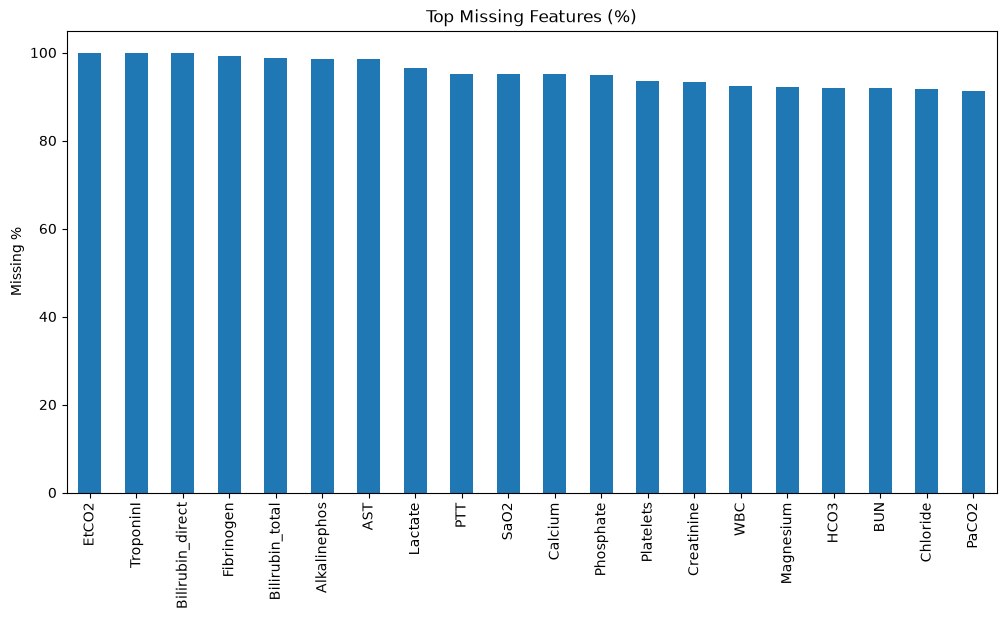

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

missing_pct = (
    df.isnull().mean()*100
).sort_values(ascending=False)

plt.figure(figsize=(12,6))

missing_pct.head(20).plot(kind='bar')

plt.title("Top Missing Features (%)")
plt.ylabel("Missing %")

plt.show()

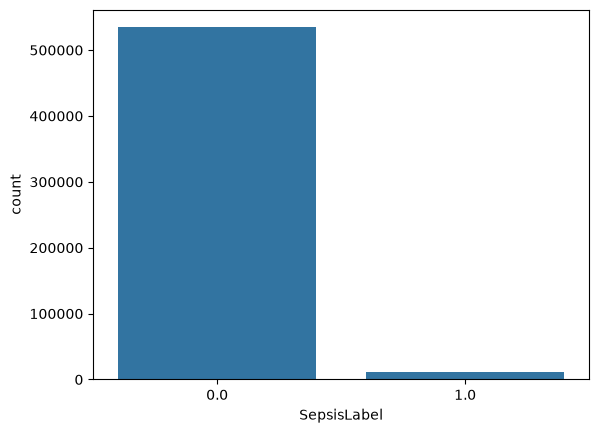

In [3]:
sns.countplot(
    x=df["SepsisLabel"]
)

plt.show()

<Axes: xlabel='Gender', ylabel='count'>

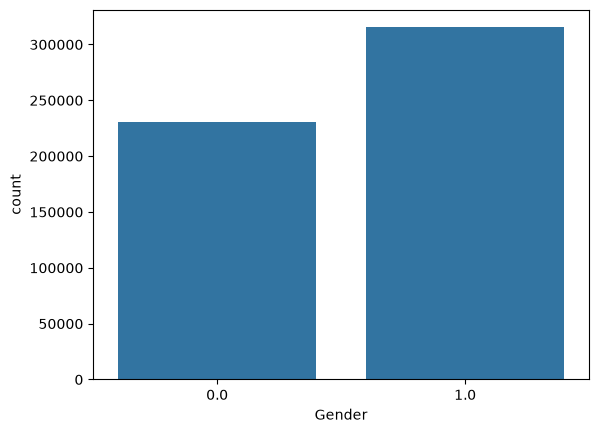

In [4]:
sns.countplot(
    x=df["Gender"]
)

In [6]:
vitals = [
    "HR",
    "O2Sat",
    "Temp",
    "SBP",
    "MAP",
    "Resp"
]

df[vitals].describe()

,HR,O2Sat,Temp,SBP,MAP,Resp
count,504000.000000,480319.000000,184511.000000,462920.000000,490527.000000,492675.000000
mean,84.936506,97.258570,37.028197,121.097229,78.865428,18.749110
std,16.933876,2.935284,0.783216,21.506672,15.057816,5.379793
min,20.000000,20.000000,21.000000,22.000000,20.000000,1.000000
25%,73.000000,96.000000,36.560000,105.000000,68.330000,15.000000
50%,84.000000,98.000000,37.060000,119.000000,77.000000,18.000000
75%,96.000000,99.500000,37.560000,135.000000,87.670000,22.000000
max,223.000000,100.000000,42.220000,274.000000,300.000000,69.000000


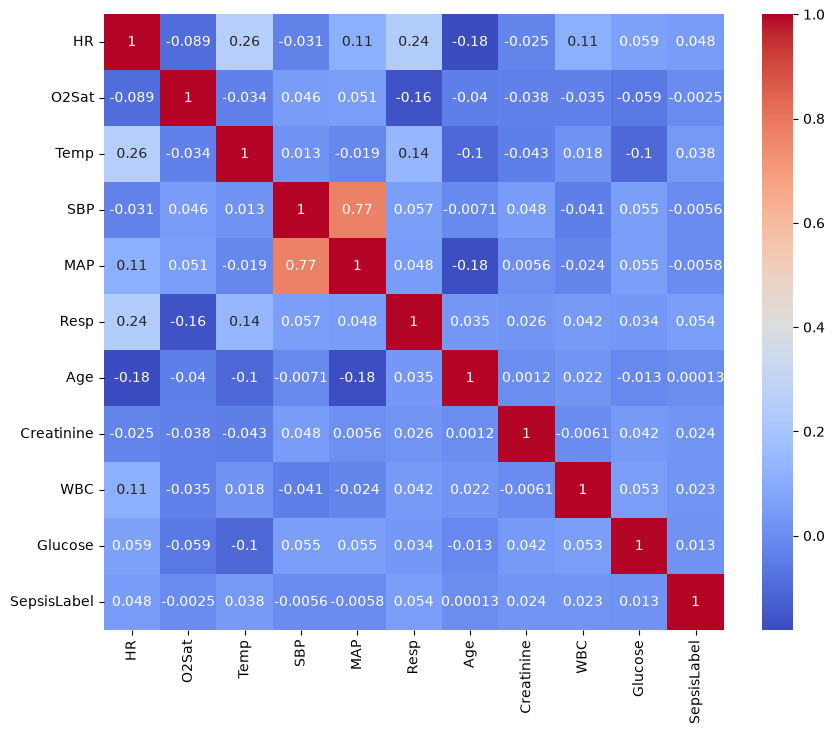

In [7]:
clinical_features = [
    "HR",
    "O2Sat",
    "Temp",
    "SBP",
    "MAP",
    "Resp",
    "Age",
    "Creatinine",
    "WBC",
    "Glucose",
    "SepsisLabel"
]

corr = df[clinical_features].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [8]:
sepsis_patients = df[df["SepsisLabel"] == 1]
non_sepsis_patients = df[df["SepsisLabel"] == 0]

In [9]:
features = [
    "HR",
    "O2Sat",
    "Temp",
    "SBP",
    "MAP",
    "Resp",
    "Creatinine",
    "WBC",
    "Glucose"
]

for col in features:
    print("\n", col)
    print("Sepsis Mean:", sepsis_patients[col].mean())
    print("Non-Sepsis Mean:", non_sepsis_patients[col].mean())


 HR
Sepsis Mean: 90.34004170066177
Non-Sepsis Mean: 84.81548122799046

 O2Sat
Sepsis Mean: 97.20934921230308
Non-Sepsis Mean: 97.25969415782683

 Temp
Sepsis Mean: 37.23569857870742
Non-Sepsis Mean: 37.02391654036353

 SBP
Sepsis Mean: 120.28171624948706
Non-Sepsis Mean: 121.11476925928622

 MAP
Sepsis Mean: 78.2807138251819
Non-Sepsis Mean: 78.87858243914033

 Resp
Sepsis Mean: 20.69630022115739
Non-Sepsis Mean: 18.705249407457526

 Creatinine
Sepsis Mean: 1.6229865771812082
Non-Sepsis Mean: 1.3895124299224193

 WBC
Sepsis Mean: 13.006962025316458
Non-Sepsis Mean: 11.84844719562929

 Glucose
Sepsis Mean: 138.1548951048951
Non-Sepsis Mean: 133.662810660008


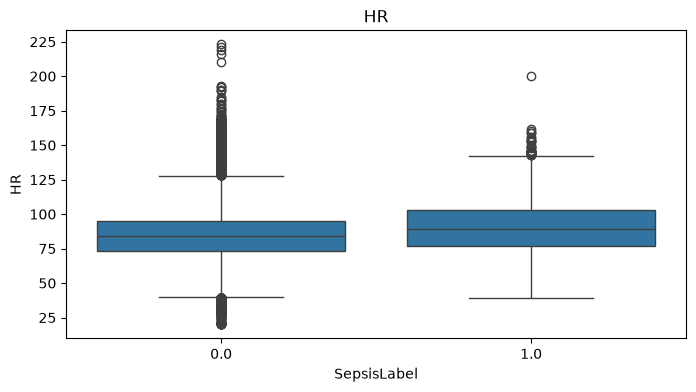

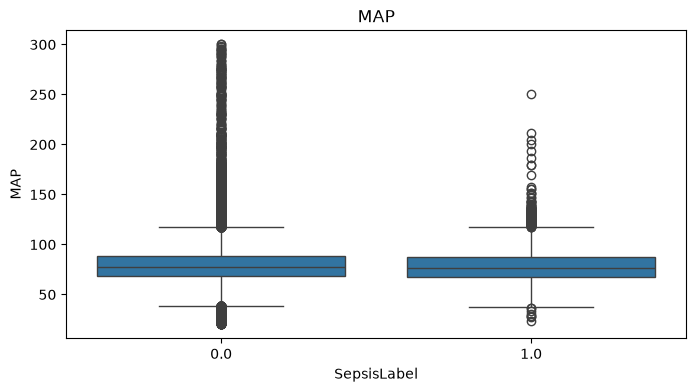

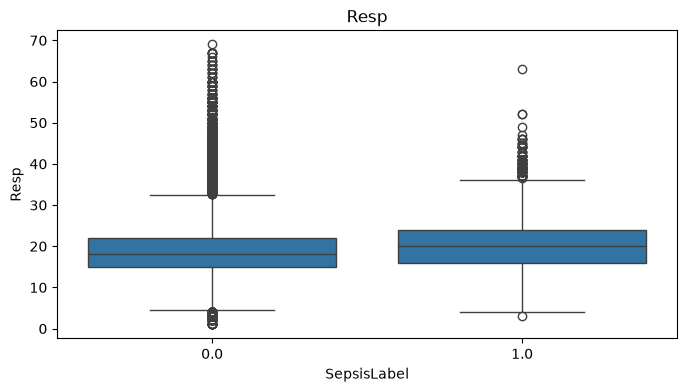

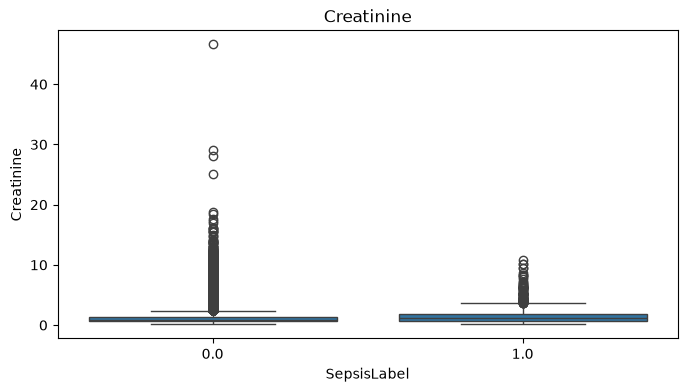

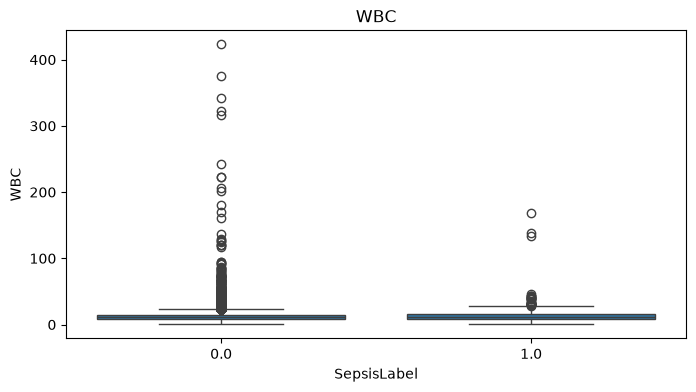

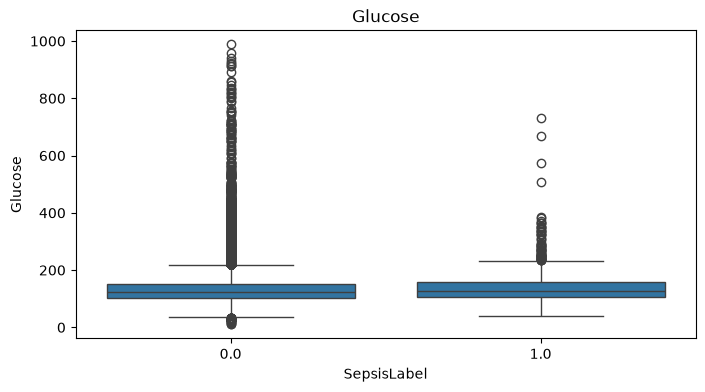

In [10]:
important = [
    "HR",
    "MAP",
    "Resp",
    "Creatinine",
    "WBC",
    "Glucose"
]

for col in important:
    plt.figure(figsize=(8,4))

    sns.boxplot(
        data=df,
        x="SepsisLabel",
        y=col
    )

    plt.title(col)

    plt.show()
    

In [11]:
df.groupby("Patient_ID")["SepsisLabel"].sum().describe()

count    14057.000000
mean         0.842996
std          2.717574
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         10.000000
Name: SepsisLabel, dtype: float64

In [12]:

df.groupby("Patient_ID")["SepsisLabel"].max().value_counts(normalize=True)*100

SepsisLabel
0.0    91.185886
1.0     8.814114
Name: proportion, dtype: float64

In [13]:
df["Patient_ID"].head()

0    17072.0
1    17072.0
2    17072.0
3    17072.0
4    17072.0
Name: Patient_ID, dtype: float64

In [14]:
df.groupby("Patient_ID").size().head()

Patient_ID
1.0    54
2.0    23
4.0    29
5.0    48
8.0    40
dtype: int64